# Spot Findr

This notebook matches spot coordinates to nuclear masks. It runs through a given series of experiments and does the following: 
1. reads in the spot detection files
2. reads the corresponding nuclear mask files
3. matches them to assign spots to nuclei/cells.

Based on that matching, it will create two data frames:
1. Spot metrics: lists the ROIs in each of the images, the XY coordinates for each of the spots within it and the fluorescence intensity for each spot in each fluorescence channel (also the "probability", inherited from Spotiflow).
2. Spot counts: lists the ROIs (nuclei/cells) in each of the images and the number of spots in that ROI in each fluorescent channel.

The notebook is intended to read in spot detection .csv files generated by Spotiflow and nuclear masks generated by Cellpose. Spot tables and masks generated by other tools should be valid too, but data formats and table structures should be verified and the code may need to be modified accordingly

In [111]:
# Import necessary packages

import os
import glob
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import logging

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
import pandas as pd
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [113]:
# Define path names and data folders to process

# Define the location of the file to read
parent_directory = "/Users/nestor/Documents/NYU-ISG/microscope-data" # modify if needed
repo_directory = "/Users/nestor/Documents/NYU-ISG/python_image-analysis" # analysis code directory
experiment_list = ["03182025_Cen-ZF_IF-FISH"]

#experiment_list = ["08052024_pDIMMERs", "08122024_pDIMMERs",
#                  "10032024_pDIMMERs", "10072024_pDIMMERs"]

#experiment_list = ["09042024_Cen-ZF_set3_session1", "09092024_Cen-ZF_set3_session2", 
#"09102024_Cen-ZF_set3_session3", "09122024_Cen-ZF_set3_session4", 
#"09172024_Cen-ZF_set3_session5", "09262024_Cen-ZF_set3_session6",
#"02032025_Cen-ZF_set4_session1", "02042025_Cen-ZF_set4_session2"] # this will be changed for each experiment

In [115]:
# Do some housekeeping first

# This dictionary defines the folder inside of "experiment" that contains masks
file_folders = {
    "mask_n": "segmentation-masks/nuclei_masks/"
}

# Load the function img_loadr() 
from load_files import img_loadr

def extract_base_name(filename):
    """
    Extract the base name from the file name without removing important parts of the name,
    such as the date and experiment information, while stripping the channel prefixes from masks.
    """
    name = os.path.basename(filename)

    # Only remove 'C1-', 'C2-', etc., from mask files
    if name.startswith(("C1-", "C2-", "C3-", "C4-", "C5-")):
        name = name[3:]  # Remove the first 3 characters (e.g., 'C1-', 'C2-', etc)
    
    # Remove the "_cp_masks" suffix for masks or ".ome" from image files if present
    name = name.replace("_cp_masks", "").replace(".ome", "")
    
    # Remove the file extension
    base_name = os.path.splitext(name)[0]
    
    return base_name

In [117]:
# CHUNK 1 # 
# Load segmentation masks for images 

# Create a dictionary to store data across multiple experiments
all_experiments_data = {}

# Iterate through each experiment in experiment_list
for experiment in experiment_list:
    # Initialize data structures for the current experiment
    exp_data = {
        "all_images": {"mask_n": []},
        "file_names": {"mask_n": []},
        "base_names": {"mask_n": []},
        "errors": []
    }

    # Process each file type using img_loadr
    with ThreadPoolExecutor(max_workers=4) as executor:
        for f in file_folders:
            file_path = os.path.join(parent_directory, experiment, file_folders[f])
            files = glob.glob(os.path.join(file_path, "*.tif"))
            results = executor.map(img_loadr, files)

            for result in results:
                image, filename = result
                if image is not None:
                    exp_data["all_images"][f].append(image)
                    exp_data["file_names"][f].append(filename)
                    exp_data["base_names"][f].append(extract_base_name(filename))
                else:
                    exp_data["errors"].append(f"Error loading {filename}")

    # Log the completion of processing for this experiment
    if exp_data["errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_data['errors'])} files.")
    else:
        logging.info(f"{experiment}: All images and masks processed successfully without errors.")
    
    # Store the experiment's data under its name
    all_experiments_data[experiment] = exp_data

# Optional: Summary of processed files for all experiments
for experiment, data in all_experiments_data.items():
    logging.info(f"{experiment}: Processed {len(data['file_names']['mask_n'])} nuclei masks.")

2025-04-01 17:18:35,743 - INFO - 03182025_Cen-ZF_IF-FISH: All images and masks processed successfully without errors.
2025-04-01 17:18:35,743 - INFO - 03182025_Cen-ZF_IF-FISH: Processed 163 nuclei masks.


In [119]:
# CHUNK 2 #
# Load spot files for each image into a dictionary

# Initialize dictionary to store spot data across multiple experiments
all_experiments_spots = {}

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Initialize data structures for the current experiment
    exp_spots = {
        "spot_files": {"spots": []},
        "spot_file_names": {"spots": []},
        "spot_base_names": {"spots": []},
        "spot_channels": [],
        "spot_errors": []
    }

    # Define the folder containing the spot files for the current experiment
    spots_folder = "spotiflow_results/"
    spots_path = os.path.join(parent_directory, experiment, spots_folder)

    # List all CSV files in the directory
    csv_files = glob.glob(os.path.join(spots_path, "*.csv"))

    # Read each CSV file and store the data and filename in the experiment's spot dictionary
    for file in csv_files:
        try:
            spots = pd.read_csv(file)  # Assumes a simple CSV structure; modify if necessary
            file_name = os.path.basename(file)

            # Extract the channel from the file name (e.g., C1, C2, etc.)
            # Assumes file name starts with C followed by a number (such as "C1-", "C2-", etc)
            channel = int(file_name.split('-')[0][1])  # Get the number after 'C'

            exp_spots["spot_files"]['spots'].append(spots)
            exp_spots["spot_file_names"]['spots'].append(file_name)  # Save the filename
            exp_spots["spot_base_names"]['spots'].append(extract_base_name(file_name))  # Store the base name
            exp_spots["spot_channels"].append(channel)  # Save the channel
            
        except Exception as e:
            exp_spots["spot_errors"].append(file)
            logging.error(f"Error reading {file} in {experiment}: {str(e)}")

    # Log completion for this experiment
    if exp_spots["spot_errors"]:
        logging.error(f"{experiment}: Completed with errors in {len(exp_spots['spot_errors'])} files.")
    else:
        logging.info(f"{experiment}: All spot files loaded successfully.")

    # Store the experiment's spot data in the main dictionary
    all_experiments_spots[experiment] = exp_spots

# Optional: Summary of processed spot files for all experiments
for experiment, data in all_experiments_spots.items():
    logging.info(f"{experiment}: Processed {len(data['spot_file_names']['spots'])} spot files.")


2025-04-01 17:18:37,598 - INFO - 03182025_Cen-ZF_IF-FISH: All spot files loaded successfully.
2025-04-01 17:18:37,599 - INFO - 03182025_Cen-ZF_IF-FISH: Processed 326 spot files.


In [121]:
# CHUNK 3 #
# Match spot files to nuclear mask files using the base_names common to all files

# Initialize a dictionary to store matched indices for each experiment
all_matched_indices_with_spots = {}

# Loop through each experiment
for experiment in experiment_list:
    # Retrieve base names for nuclear masks and spot files in the current experiment
    mask_base_names = all_experiments_data[experiment]["base_names"]["mask_n"]
    spot_base_names = all_experiments_spots[experiment]["spot_base_names"]["spots"]

    # Convert list of spot base names to a dictionary for faster lookup
    spot_name_to_index = {base_name: idx for idx, base_name in enumerate(spot_base_names)}

    # Initialize lists and counters for matched indices and missing spots
    matched_indices_with_spots = []
    missing_spots = 0

    # Match each nuclear mask with its corresponding spot file
    for mask_index, mask_base_name in enumerate(mask_base_names):
        spot_index = spot_name_to_index.get(mask_base_name)  # Use base names to match

        if spot_index is not None:
            matched_indices_with_spots.append((mask_index, spot_index))
        else:
            missing_spots += 1
            logging.warning(f"No matching spot file found for mask: {all_experiments_data[experiment]['file_names']['mask_n'][mask_index]} in {experiment}")

    # Store matched indices for the current experiment
    all_matched_indices_with_spots[experiment] = matched_indices_with_spots

    # Log the results of the matching for the current experiment
    logging.info(f"{experiment}: Matched {len(matched_indices_with_spots)} nuclear masks with spot files. Missing spot files for {missing_spots} masks.")

# Optional: Summary of matched indices for all experiments
for experiment, matched_indices in all_matched_indices_with_spots.items():
    logging.info(f"{experiment}: Total matched nuclear masks with spots - {len(matched_indices)}")


2025-04-01 17:18:39,907 - INFO - 03182025_Cen-ZF_IF-FISH: Matched 163 nuclear masks with spot files. Missing spot files for 0 masks.
2025-04-01 17:18:39,910 - INFO - 03182025_Cen-ZF_IF-FISH: Total matched nuclear masks with spots - 163


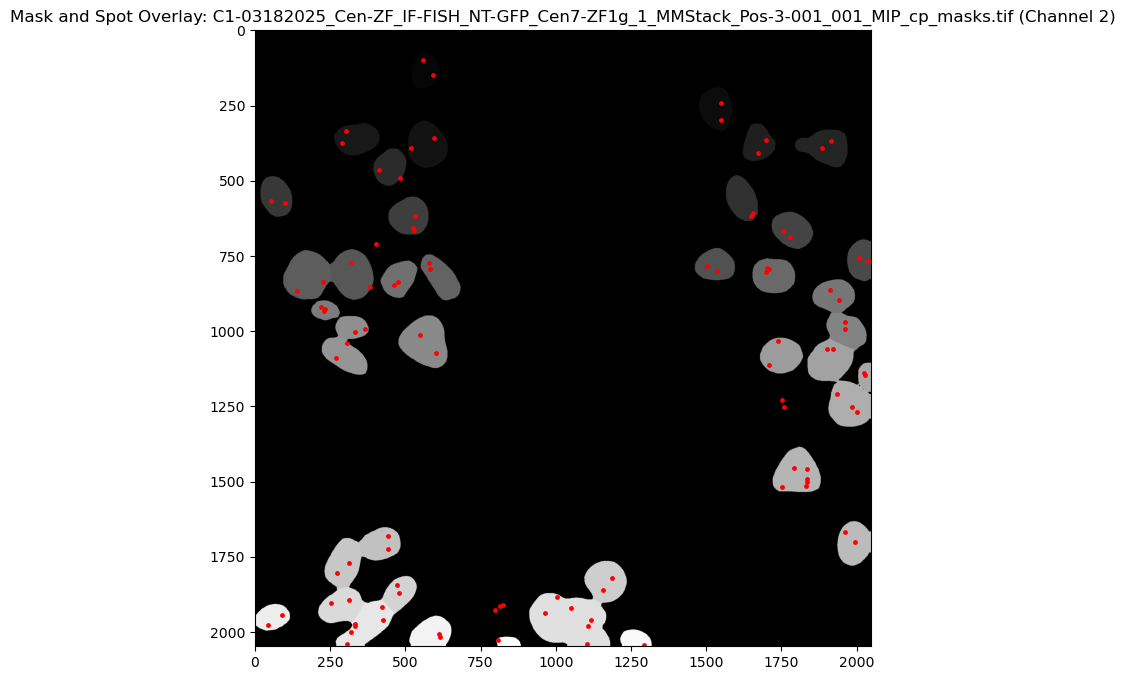

In [129]:
# Overlay a mask and its spot coordinates for visual confirmation that
# a) match was correct
# b) XY axes align on both images

# Pick an experiment from experiment_list, an image and a channel to overlay, using indices
e = 0 # index for experiment (from 0 to length(experiment_list - 1))
experiment = experiment_list[e]
i = 25 # image index (1 - (n images -1))
c = 2 # channel to overlay (1-index, from C1-, C2, C3-)

# Retrieve the matched indices for the selected experiment
matched_indices = all_matched_indices_with_spots[experiment]
mask_index, spot_index = matched_indices[i]

# Access mask and spot data for the chosen experiment and indices
mask = all_experiments_data[experiment]['all_images']['mask_n'][mask_index]
mask_base_name = all_experiments_data[experiment]['base_names']['mask_n'][mask_index]

# Find the corresponding spot file for the chosen channel
spot_found = False
for j, spot_base_name in enumerate(all_experiments_spots[experiment]['spot_base_names']['spots']):
    if spot_base_name == mask_base_name and all_experiments_spots[experiment]['spot_channels'][j] == c:
        spots = all_experiments_spots[experiment]['spot_files']['spots'][j]
        spot_found = True
        break

# Proceed with plotting if the corresponding spot file for the chosen channel is found
if spot_found:
    # The spot files have 'x' and 'y' as labels for columns containing coordinates
    x_coords = spots['x']
    y_coords = spots['y']

    # Plot the mask
    plt.figure(figsize=(8, 8))
    plt.imshow(mask, cmap='gray')
    plt.scatter(x_coords, y_coords, color='red', s=6)  # Overlay spots in red
    plt.title(f"Mask and Spot Overlay: {all_experiments_data[experiment]['file_names']['mask_n'][mask_index]} (Channel {c})")
    plt.show()
else:
    print(f"No spot data found for channel {c} at index {i} in experiment {experiment}.")

In [131]:
# CHUNK 4 (updated using base_names) #
# Assign each spot to a nuclear mask ROI based on their coordinates

# Generate a dictionary to hold the number of spots per ROI for all experiments
spot_counts_per_roi = {}
# and a list to store spot metrics data
spot_metrics_data = []

# Loop through each experiment
for experiment in experiment_list:
    # Retrieve matched indices for the current experiment
    matched_indices = all_matched_indices_with_spots[experiment]
    
    # Retrieve data for masks and spots for the current experiment
    mask_base_names = all_experiments_data[experiment]['base_names']['mask_n']
    masks = all_experiments_data[experiment]['all_images']['mask_n']
    spot_files = all_experiments_spots[experiment]['spot_files']['spots']
    spot_channels = all_experiments_spots[experiment]['spot_channels']

    # Iterate through each matched mask and spot file
    for mask_base_name, (mask_index, spot_index) in zip(mask_base_names, matched_indices):
        my_mask = masks[mask_index]
        spot_coords = spot_files[spot_index]
        channel = spot_channels[spot_index]  # Get the channel for the current spot file

        # Get all unique ROI values in the mask (excluding background 0) and initialize them with zero spot count
        unique_rois = np.unique(my_mask)
        for roi_value in unique_rois:
            if roi_value != 0:  # Skip background
                key = (experiment, mask_base_name, roi_value, channel)  # Key includes experiment, mask base name, ROI, and channel
                if key not in spot_counts_per_roi:
                    spot_counts_per_roi[key] = 0  # Initialize ROI with zero spots

        # Extract x, y, intensity, and probability from the spot file
        # Round the coordinates for indexing
        x_coords = np.round(spot_coords['x']).values.astype(int)
        y_coords = np.round(spot_coords['y']).values.astype(int)
        intensities = spot_coords['intensity'].values
        probabilities = spot_coords['probability'].values


        # Assign each spot to an ROI in the mask based on coordinates, and record metrics
        for x, y, intensity, probability in zip(x_coords, y_coords, intensities, probabilities):
            # Ensure the spot's coordinates are within the mask's bounds
            if 0 <= y < my_mask.shape[0] and 0 <= x < my_mask.shape[1]:
                roi_value = my_mask[y, x]  # The value in the mask at the spot's location
                if roi_value != 0:  # Skip background
                    key = (experiment, mask_base_name, roi_value, channel)
                    spot_counts_per_roi[key] += 1  # Increment the spot count for the ROI

                    # Append the spot's metrics as a new record
                    spot_metrics_data.append({
                        'experiment': experiment,
                        'base_name': mask_base_name,
                        'ROI': roi_value,
                        'channel': channel,
                        'x': x,
                        'y': y,
                        'intensity': intensity,
                        'probability': probability
                    })

In [132]:
# Convert the dictionaries above to Pandas data frames

# Create a DataFrame from the spot_counts dictionary 
# that contains spot counts for each ROI in each image and channel
spot_counts = pd.DataFrame([
    {
        'experiment': experiment,
        'base_name': base_name,
        'ROI': roi,
        'channel': channel,
        'spot_count': count
    }
    for (experiment, base_name, roi, channel), count in spot_counts_per_roi.items()
])

# Convert the spot_metrics list to a second data frame, 
# that contains the x, y, intensity and probabilty for each spot with assigned ROI, image and channel
spot_metrics = pd.DataFrame(spot_metrics_data)

In [133]:
# Display a sample of each DataFrame for inspection
print("Spot Counts DataFrame:")
print(spot_counts.head(10))
print("\nSpot Metrics DataFrame:")
print(spot_metrics.head(10))

Spot Counts DataFrame:
                experiment                                          base_name  \
0  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
1  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
2  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
3  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
4  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
5  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
6  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
7  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
8  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
9  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   

   ROI  channel  spot_count  
0    1        2           1  
1    2        2          

In [137]:
# CHUNK 5 #
# Read in the experimental groups reference files for each experiment (metadata)

# Initialize a list to hold the experimental group DataFrames for each experiment
exp_groups_list = []

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Build the path to the experimental-groups.csv file
    csv_path = os.path.join(parent_directory, experiment, "experimental-groups.csv")
    try:
        # Read the CSV file
        exp_df = pd.read_csv(csv_path)
        
        # If the file contains a column called "experiment_folder", rename it to "experiment"
        if 'experiment_folder' in exp_df.columns:
            exp_df = exp_df.rename(columns={'experiment_folder': 'experiment'})
        
        # If neither "experiment_folder" nor "experiment" is present, create a new column
        if 'experiment' not in exp_df.columns:
            exp_df['experiment'] = experiment
        
        # Append the DataFrame to the list
        exp_groups_list.append(exp_df)
        
    except Exception as e:
        logging.error(f"Error reading {csv_path} for experiment {experiment}: {str(e)}")

# Combine all experimental groups into a single DataFrame
exp_groups = pd.concat(exp_groups_list, ignore_index=True)

# Update the "filename" column in experimental_groups by replacing ".ome.tif" at the end with "_MIP"
# to match the format of other tables
exp_groups['filename'] = exp_groups['filename'].str.replace(r'\.ome\.tif$', '_MIP', regex=True)

# Rename "filename" to "base_name" as in spots counts file
exp_groups.rename(columns = {"filename": "base_name"}, inplace = True)

# Optionally, inspect the combined DataFrame
print(exp_groups.head())

                experiment                                          base_name  \
0  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen1-ZF1c_1_MMS...   
1  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen1-ZF1c_1_MMS...   
2  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen1-ZF1c_1_MMS...   
3  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen1-ZF1c_1_MMS...   
4  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen1-ZF1c_1_MMS...   

            plasmid  
0  NT-GFP_Cen1-ZF1c  
1  NT-GFP_Cen1-ZF1c  
2  NT-GFP_Cen1-ZF1c  
3  NT-GFP_Cen1-ZF1c  
4  NT-GFP_Cen1-ZF1c  


In [139]:
# Optional: print an instance of base_name from exp_groups and spot_counts 
# to confirm format matches
print(exp_groups['base_name'][0])
print(spot_counts['base_name'][0])

03182025_Cen-ZF_IF-FISH_NT-GFP_Cen1-ZF1c_1_MMStack_Pos-8-000_000_MIP
03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMStack_Pos-3-002_002_MIP


In [141]:
# Optional: incorporate exp_groups metadata into spot_counts and spot_metrics data frames
# >> you'll want to do this if your exp_groups file has more information than "experiment" and "base_name"
spot_counts = pd.merge(spot_counts, 
                       exp_groups, 
                       on = ["experiment", "base_name"], how = 'left')
spot_metrics = pd.merge(spot_metrics, 
                       exp_groups, 
                       on = ["experiment", "base_name"], how = 'left')

In [143]:
print(spot_counts.head())
print(spot_metrics.head())

                experiment                                          base_name  \
0  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
1  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
2  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
3  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
4  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   

   ROI  channel  spot_count           plasmid  
0    1        2           1  NT-GFP_Cen7-ZF1g  
1    2        2           3  NT-GFP_Cen7-ZF1g  
2    3        2           2  NT-GFP_Cen7-ZF1g  
3    4        2           3  NT-GFP_Cen7-ZF1g  
4    5        2           2  NT-GFP_Cen7-ZF1g  
                experiment                                          base_name  \
0  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7-ZF1g_1_MMS...   
1  03182025_Cen-ZF_IF-FISH  03182025_Cen-ZF_IF-FISH_NT-GFP_Cen7

In [145]:
# FILE SAVING # 

# Files will be saved in the "results" folder of the analysis repository
results_dir = os.path.join(repo_directory, "results")

# Files for each experiment will be saved in their own folder as .csv files
# They can subsequently be read in and joined as needed
# This is more versatile than combining data from multiple experiments into a single big .csv file

# Get today's date string to use as a suffix
import datetime
date_suffix = datetime.datetime.now().strftime("%m%d%Y")

# Loop through each experiment in experiment_list
for experiment in experiment_list:
    # Define the folder for the current experiment inside the results folder
    experiment_folder = os.path.join(results_dir, experiment)
    
    # Create the folder if it doesn't already exist
    os.makedirs(experiment_folder, exist_ok=True)
    
    # Filter the DataFrames for the current experiment.
    # (Assumes your spot_counts and spot_metrics DataFrames include an "experiment" column.)
    spot_counts_exp = spot_counts[spot_counts['experiment'] == experiment]
    spot_metrics_exp = spot_metrics[spot_metrics['experiment'] == experiment]
    
    # Define the default file paths for the CSV files
    spot_counts_file = os.path.join(experiment_folder, "spot_counts-raw.csv")
    spot_metrics_file = os.path.join(experiment_folder, "spot_metrics-raw.csv")
    
    # If the spot_counts file already exists, add the date suffix to create a new filename.
    if os.path.exists(spot_counts_file):
        spot_counts_file = os.path.join(experiment_folder, f"spot_counts_{date_suffix}.csv")
    
    # If the spot_metrics file already exists, add the date suffix to create a new filename.
    if os.path.exists(spot_metrics_file):
        spot_metrics_file = os.path.join(experiment_folder, f"spot_metrics_{date_suffix}.csv")
    
    # Save the DataFrames to their respective CSV files
    spot_counts_exp.to_csv(spot_counts_file, index=False)
    spot_metrics_exp.to_csv(spot_metrics_file, index=False)

## Spot filtering

The code below builds on the spot detection above but tries to filter true spots for each cell

In [17]:
# Read in the cell classification generated by me with img-explorer.ipynb
cell_clx = pd.read_csv(os.path.join(repo_directory, "results/", "Cen-ZFs_select_HCT116_all_class.csv"))
cell_clx.rename(columns = {'filename': 'base_name', 
                           'ROI_index': 'ROI'}, inplace = True)

# And also the data frame with fluorescent intensities generated with img-explorer.ipynb
cell_metrix = pd.read_csv(os.path.join(repo_directory, "results/", "Cen-ZFs_select_HCT116_all.csv"))
cell_metrix.rename(columns = {'filename': 'base_name',
                              'ROI_index': 'ROI'}, inplace = True)

# Adjust the channel numbers in cell_metrix so they match spot_metrics
cell_metrix['channel'] = cell_metrix['channel'] + 1

In [19]:
# Merge spot_counts with my cell classification
spot_counts = pd.merge(spot_counts, 
                   cell_clx[['plasmid', 'experiment', 'base_name', 'ROI', 'tx_status_thr', 'tx_status_gmm', 'cor_ch1_log10_median']], 
                   on = ['base_name', 'experiment', 'ROI'], how = 'inner')

In [21]:
# Incorporate ROI median intensity into spots_metrics data frame
spot_metrics = pd.merge(
    spot_metrics,
    cell_metrix[['plasmid', 'experiment', 'base_name', 'ROI', 'channel', 'median']],
    on = ['base_name', 'experiment', 'ROI', 'channel'], 
    how = 'inner'
)

In [23]:
# Calculate the signal-to-background ratio as the spot intensity divided by ROI median intensity
spot_metrics['sbr'] = spot_metrics['intensity'] / spot_metrics['median']

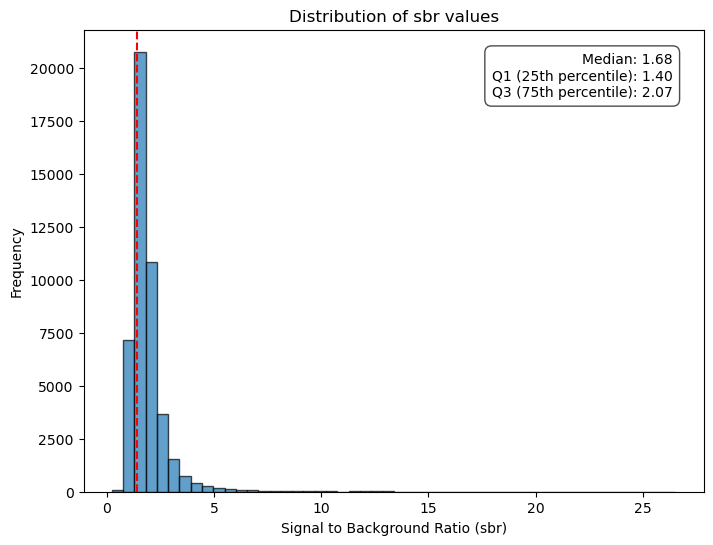

In [33]:
# Visualize the distribution of SBR values as a histogram

# Drop any NaN values that might have been created due to division by zero or missing data.
sbr_values = spot_metrics['sbr'].dropna()

# Compute statistics: median, 25th percentile (Q1) and 75th percentile (Q3)
median_val = np.median(sbr_values)
q1, q3 = np.percentile(sbr_values, [25, 75])

# Create histogram
plt.figure(figsize=(8, 6))
plt.hist(sbr_values, bins=50, edgecolor='black', alpha=0.7)

# Add a vertical dashed line at Q1
plt.axvline(q1, color='red', linestyle='dashed', linewidth=1.5, label=f"Q1: {q1:.2f}")

plt.xlabel('Signal to Background Ratio (sbr)')
plt.ylabel('Frequency')
plt.title('Distribution of sbr values')

# Add text box with median and quartiles
stats_text = f"Median: {median_val:.2f}\nQ1 (25th percentile): {q1:.2f}\nQ3 (75th percentile): {q3:.2f}"
plt.text(0.95, 0.95, stats_text, transform=plt.gca().transAxes,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7))

plt.show()

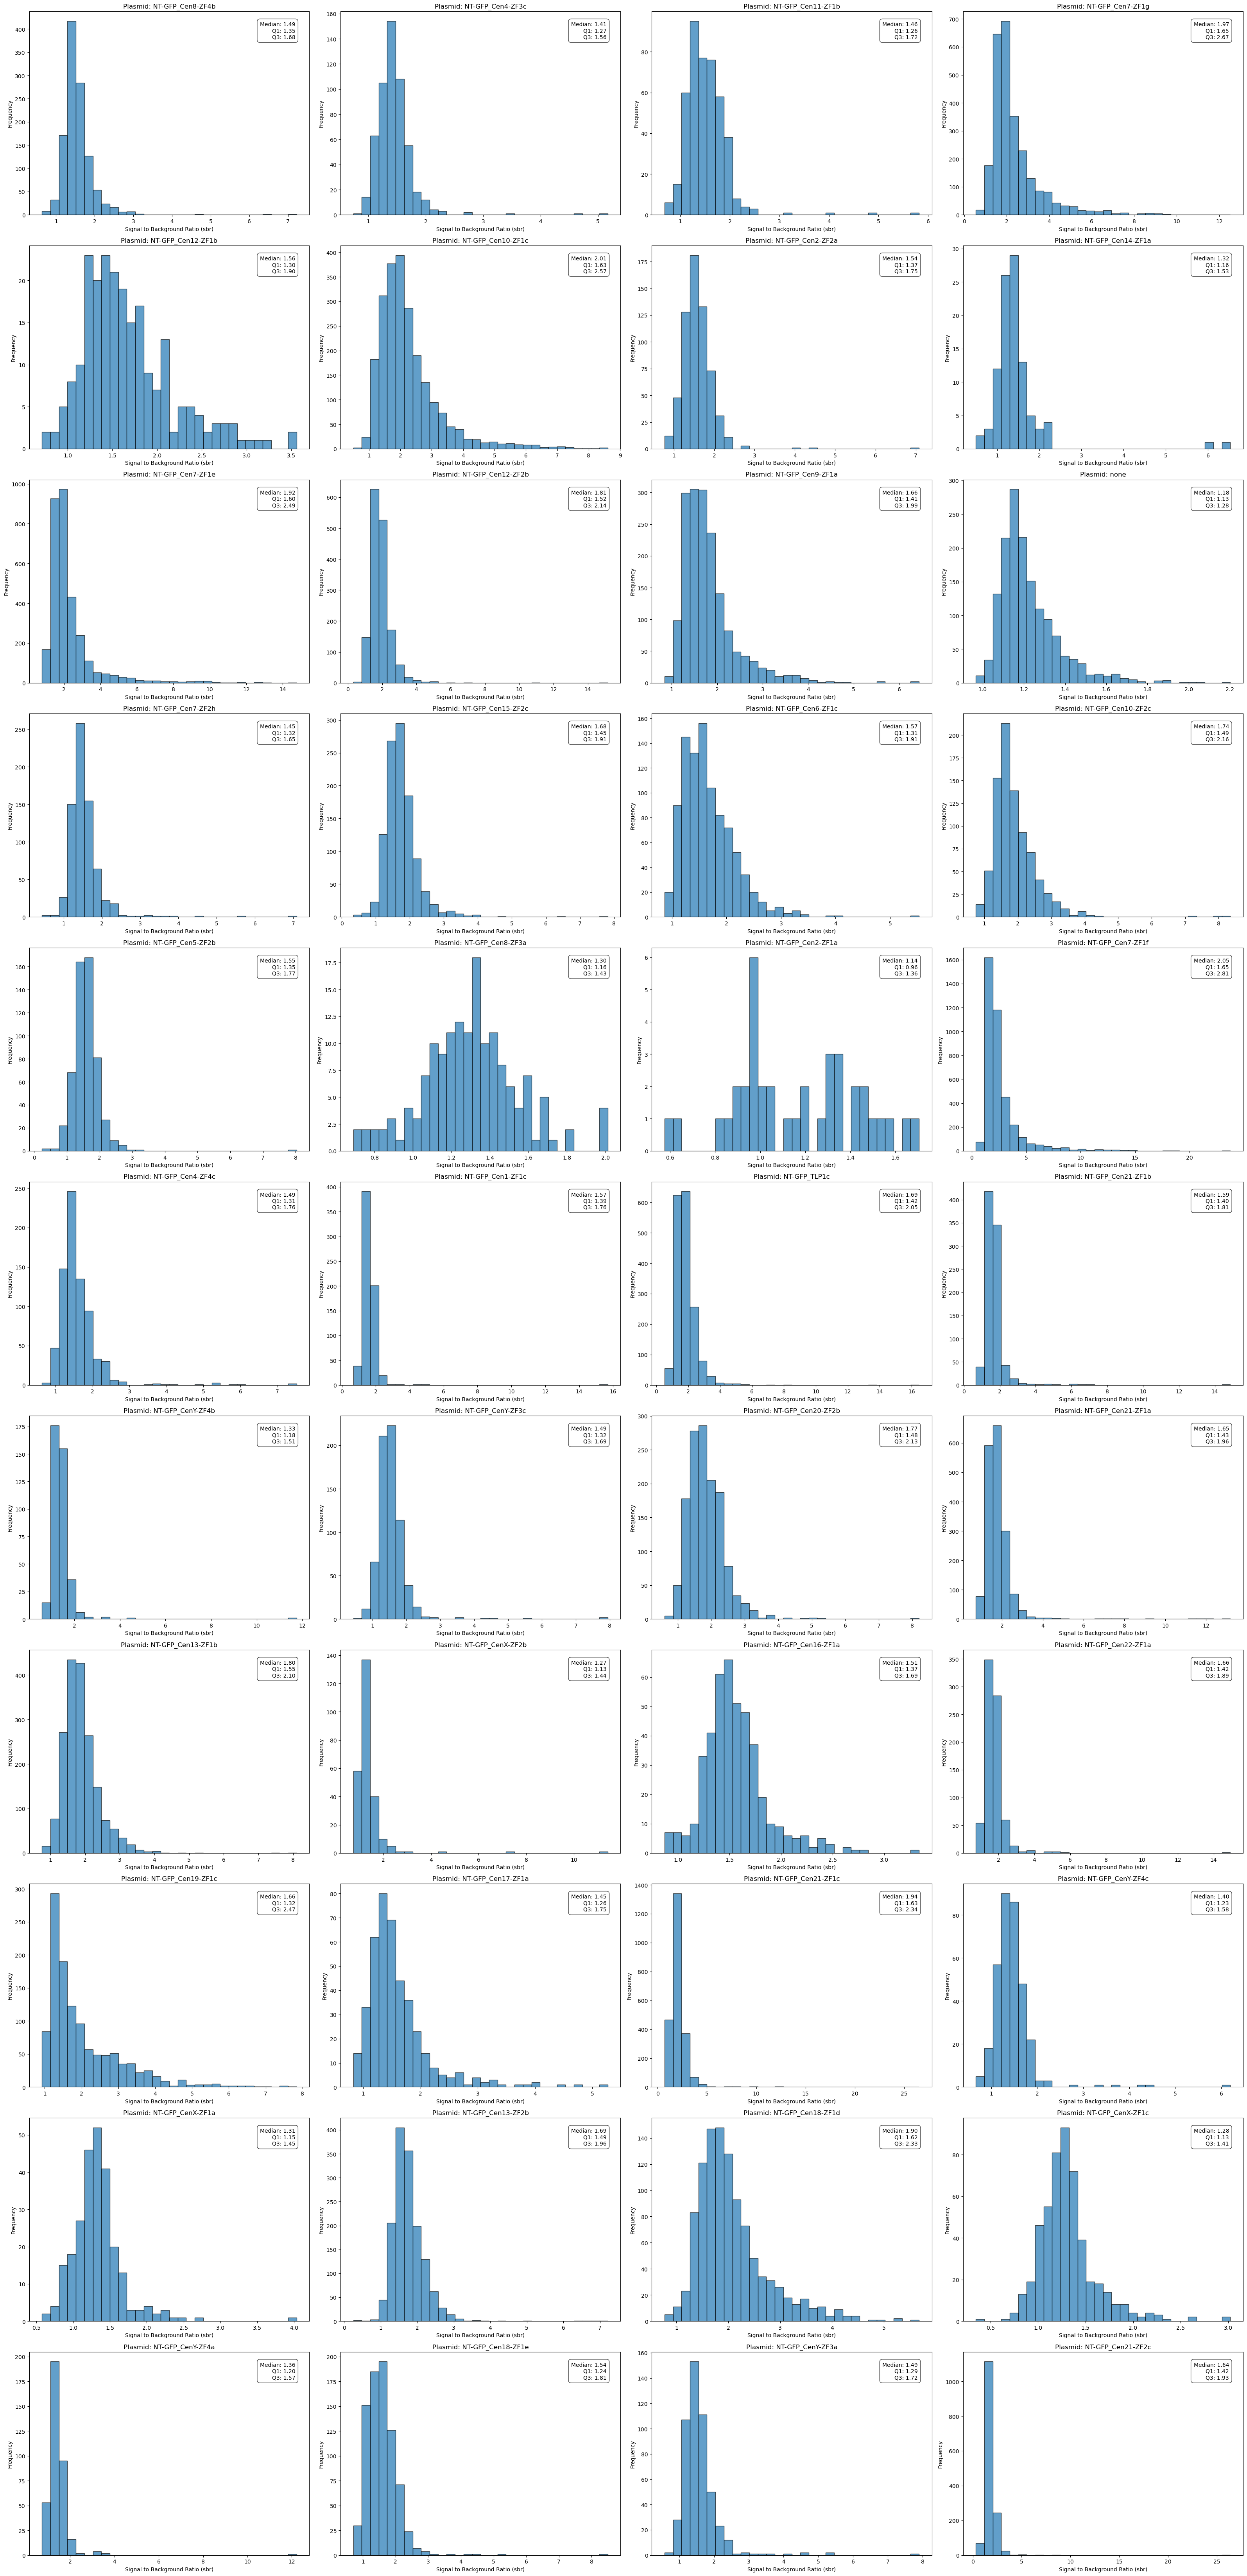

In [25]:
# Visualize the distribution of SBR values as a histogram, by plasmid

# Get unique plasmid values
plasmids = spot_metrics['plasmid'].unique()
num_plasmids = len(plasmids)

# Define the grid layout (adjust ncols as needed)
ncols = 4
nrows = int(np.ceil(num_plasmids / ncols))

# Create the figure and axes array
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * nrows))
axes = axes.flatten()  # Flatten in case we have multiple rows/columns

for i, plasmid in enumerate(plasmids):
    ax = axes[i]
    # Filter the data for the current plasmid and drop NaN sbr values
    plasmid_data = spot_metrics.loc[spot_metrics['plasmid'] == plasmid, 'sbr'].dropna()
    
    # Compute statistics for the current plasmid
    median_val = np.median(plasmid_data)
    q1, q3 = np.percentile(plasmid_data, [25, 75])
    
    # Plot the histogram for the current plasmid
    ax.hist(plasmid_data, bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'Plasmid: {plasmid}')
    ax.set_xlabel('Signal to Background Ratio (sbr)')
    ax.set_ylabel('Frequency')
    
    # Add a text box with statistics in the top-right corner
    stats_text = f"Median: {median_val:.2f}\nQ1: {q1:.2f}\nQ3: {q3:.2f}"
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7))

# Remove any unused subplots if the total number of plasmids is less than nrows*ncols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Filter spots based on the calculated SBR, **for each plasmid**

# Step 1: Filter spot_metrics within each plasmid group
filtered_spots = spot_metrics.groupby('plasmid').apply(
    lambda group: group[group['sbr'] >= np.percentile(group['sbr'].dropna(), 25)]
).reset_index(drop=True)

# Step 2: Group the filtered data by the specified columns and count the number of spots per group.
spot_filter_counts = filtered_spots.groupby(['experiment', 'base_name', 'ROI', 'channel']).size().reset_index(name='spot_count')

# Merge spot_counts with my cell classification
spot_filter_counts = pd.merge(
    cell_clx[['plasmid', 'experiment', 'base_name', 'ROI', 'tx_status_thr', 'tx_status_gmm', 'cor_ch1_log10_median']], 
    spot_filter_counts[['experiment', 'base_name', 'ROI', 'spot_count']], 
    on = ['base_name', 'experiment', 'ROI'], 
    how = 'left'
)

spot_filter_counts['spot_count'] = spot_filter_counts['spot_count'].fillna(0).astype(int)

# Visualize the result
print(spot_filter_counts.head(10))

In [35]:
# Filter spots based on the calculated SBR, **globally**

# Step 1: Filter spot_metrics to include only spots with sbr >= 25th percentile.
# Calculate the 25th percentile (Q1) of sbr values
q1 = np.percentile(spot_metrics['sbr'].dropna(), 25)
filtered_spots = spot_metrics[spot_metrics['sbr'] >= q1].copy() 

# Step 2: Group the filtered data by the specified columns and count the number of spots per group.
spot_filter_counts = filtered_spots.groupby(['experiment', 'base_name', 'ROI', 'channel']).size().reset_index(name='spot_count')

# Merge spot_counts with my cell classification
spot_filter_counts = pd.merge(
    cell_clx[['plasmid', 'experiment', 'base_name', 'ROI', 'tx_status_thr', 'tx_status_gmm', 'cor_ch1_log10_median']], 
    spot_filter_counts[['experiment', 'base_name', 'ROI', 'spot_count']], 
    on = ['base_name', 'experiment', 'ROI'], how = 'left'
)

spot_filter_counts['spot_count'] = spot_filter_counts['spot_count'].fillna(0).astype(int)

# Visualize the result
print(spot_filter_counts.head(10))

            plasmid                              experiment  \
0  NT-GFP_Cen7-ZF1g  02112025_Cen-ZF_select_HCT116_session1   
1  NT-GFP_Cen7-ZF1g  02112025_Cen-ZF_select_HCT116_session1   
2  NT-GFP_Cen7-ZF1g  02112025_Cen-ZF_select_HCT116_session1   
3  NT-GFP_Cen7-ZF1g  02112025_Cen-ZF_select_HCT116_session1   
4  NT-GFP_Cen7-ZF1g  02112025_Cen-ZF_select_HCT116_session1   
5  NT-GFP_Cen7-ZF1g  02112025_Cen-ZF_select_HCT116_session1   
6  NT-GFP_Cen7-ZF1g  02112025_Cen-ZF_select_HCT116_session1   
7  NT-GFP_Cen7-ZF1g  02112025_Cen-ZF_select_HCT116_session1   
8  NT-GFP_Cen7-ZF1g  02112025_Cen-ZF_select_HCT116_session1   
9  NT-GFP_Cen7-ZF1g  02112025_Cen-ZF_select_HCT116_session1   

                                           base_name  ROI tx_status_thr  \
0  02112025_Cen-ZF_select_HCT116_NT-GFP_Cen7-ZF1g...    1             N   
1  02112025_Cen-ZF_select_HCT116_NT-GFP_Cen7-ZF1g...    2             N   
2  02112025_Cen-ZF_select_HCT116_NT-GFP_Cen7-ZF1g...    3             N   
3  021

In [39]:
# Save the spot counts to a .csv file on disk
spot_counts.to_csv(os.path.join(repo_directory, "results/", "Cen-ZFs_select_HCT116_spot-counts.csv"), index = False)
spot_filter_counts.to_csv(os.path.join(repo_directory, "results/", "Cen-ZFs_select_HCT116_spot-filter2-counts.csv"), index = False)

/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_histogram : Removed 16 rows containing missing values.


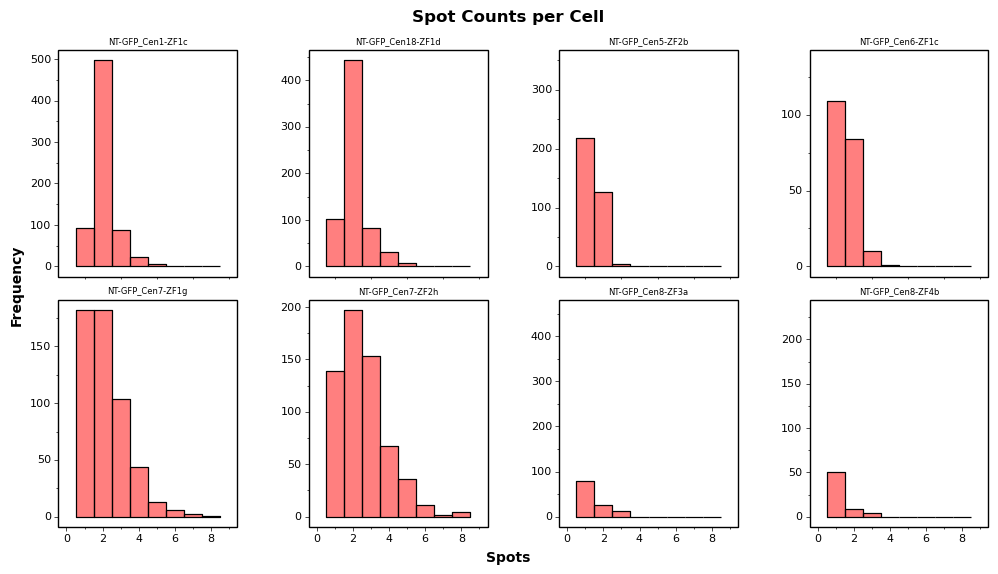

In [129]:
# Plot the number of spots found for all ROIs in all images

# Define a dictionary of channel colors
channel_colors = {1: 'blue', 2: 'cyan', 3: 'red'}

# Define some list of values to filter by
#my_plasmids = []
#aug_experiments = ['08052024_pDIMMERs', '08122024_pDIMMERs']
#oct_experiments = ['10032024_pDIMMERs', '10072024_pDIMMERs']

# Reorder channels so that Channel 2 (GFP) is plotted over Channel 3 (FISH)
#spot_filter_counts['channel'] = pd.Categorical(spot_filter_counts['channel'], categories=[3, 2], ordered=True)

#my_spots = spot_filter_counts[(spot_filter_counts['experiment'] == experiment_list[0]) & 
#(spot_filter_counts['tx_status_gmm'] == 'Y') & (spot_filter_counts['spot_count'] <= 10)] 
# & 
# & 
#(spot_df['plasmid'] != "none")
#my_spots['channel'] = 2

my_spots = spot_counts[spot_counts['channel'] == 3]

# Determine the largest number of spots to set the X axis of the plot
#max_spot_count = spot_df['spot_count'].max()
max_spot_count = 8

# Define the plot with overlaid histograms for each channel
spot_histogram = (
    p9.ggplot(my_spots, 
              p9.aes(x = 'spot_count', 
                     fill = 'factor(channel)')) +  # Set the data and x-axis aesthetic
    p9.geom_histogram(binwidth = 1, color = 'black', 
                      alpha = 0.5, position = 'identity') +  # Overlaid histograms
    p9.labs(title = 'Spot Counts per Cell', 
            x = 'Spots', y = 'Frequency', fill = 'Channel') +  # Add labels
    p9.facet_wrap(' ~ plasmid', scales = "free_y", nrow = 2) +
    #p9.facet_wrap(' ~ plasmid', scales = 'free_y', nrow = 1) +
    p9.scale_fill_manual(values = channel_colors) +  # Apply the custom channel colors
    p9.scale_x_continuous(limits = [0, max_spot_count+1], breaks = range(0, max_spot_count + 1, 2)) + 
    p9.theme_bw() +  # Apply theme
    p9.theme(figure_size = (12, 6),
             subplots_adjust = {'wspace': 0.4},  # Adjust space between plots
             aspect_ratio = 1,
             panel_grid = p9.element_blank(), 
             panel_border = p9.element_rect(color='black', linewidth=1), 
             axis_ticks = p9.element_line(color='black', linewidth=0.5), 
             plot_title = p9.element_text(size=12, color='black', face='bold'),
             axis_text = p9.element_text(size=8, color='black'), 
             axis_title = p9.element_text(size=10, color='black', face='bold'), 
             legend_text = p9.element_text(size=8, color='black'), 
             legend_title = p9.element_text(size=10, color='black', face='bold'),
             legend_position = 'none',
             strip_background = p9.element_blank(), 
             strip_text = p9.element_text(size=6, color='black'))
)

# Display the plot
print(spot_histogram)

In [ ]:
exp_groups.rename(columns = {'filename': 'base_name'}, inplace = True)
exp_groups['base_name'] = exp_groups['base_name'].apply(lambda x:removesuffix(".tif"))

In [57]:
exp_groups['base_name'] = exp_groups['base_name'].apply(lambda x: x.removesuffix(".tif"))

In [31]:
print(exp_groups.head())
print(spot_df.head())

                        experiment_folder  \
0  02132025_Cen-ZF_select_HCT116_session2   
1  02132025_Cen-ZF_select_HCT116_session2   
2  02132025_Cen-ZF_select_HCT116_session2   
3  02132025_Cen-ZF_select_HCT116_session2   
4  02132025_Cen-ZF_select_HCT116_session2   

                                            filename            plasmid  
0  02132025_Cen-ZF_select_HCT116_NT-GFP_Cen13-ZF1...  NT-GFP_Cen13-ZF1b  
1  02132025_Cen-ZF_select_HCT116_NT-GFP_Cen13-ZF1...  NT-GFP_Cen13-ZF1b  
2  02132025_Cen-ZF_select_HCT116_NT-GFP_Cen13-ZF1...  NT-GFP_Cen13-ZF1b  
3  02132025_Cen-ZF_select_HCT116_NT-GFP_Cen13-ZF1...  NT-GFP_Cen13-ZF1b  
4  02132025_Cen-ZF_select_HCT116_NT-GFP_Cen13-ZF1...  NT-GFP_Cen13-ZF1b  
                               experiment  \
0  02112025_Cen-ZF_select_HCT116_session1   
1  02112025_Cen-ZF_select_HCT116_session1   
2  02112025_Cen-ZF_select_HCT116_session1   
3  02112025_Cen-ZF_select_HCT116_session1   
4  02112025_Cen-ZF_select_HCT116_session1   

              

In [65]:
spot_df = pd.merge(spot_df, exp_groups[['base_name', 'plasmid']], on = ['base_name'], how = "left")
print(spot_df.head())

                 experiment                                      base_name  \
0  11252024_Taka_pombe_test  11252024_Methanol2_1_MMStack_5-Pos002_003_MIP   
1  11252024_Taka_pombe_test  11252024_Methanol2_1_MMStack_5-Pos002_003_MIP   
2  11252024_Taka_pombe_test  11252024_Methanol2_1_MMStack_5-Pos002_003_MIP   
3  11252024_Taka_pombe_test  11252024_Methanol2_1_MMStack_5-Pos002_003_MIP   
4  11252024_Taka_pombe_test  11252024_Methanol2_1_MMStack_5-Pos002_003_MIP   

   ROI  channel  spot_count   plasmid  
0    1        2           2  Methanol  
1    2        2           4  Methanol  
2    3        2           4  Methanol  
3    4        2           1  Methanol  
4    5        2           0  Methanol  


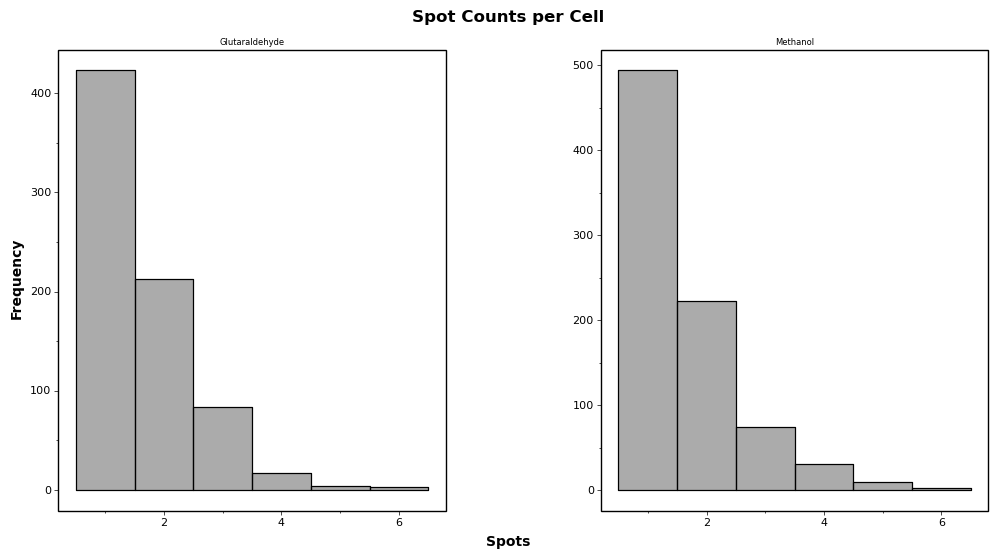

In [83]:
# Plot the number of spots found for all ROIs in all images

# Reorder channels so that Channel 2 (GFP) is plotted over Channel 3 (FISH)
spot_df['channel'] = pd.Categorical(spot_df['channel'], categories=[3, 2], ordered=True)

# Determine the largest number of spots to set the X axis of the plot
max_spot_count = spot_df['spot_count'].max()
#max_spot_count = 10

my_spots = spot_df[(spot_df['spot_count'] > 0)]

# Define the plot with overlaid histograms for each channel
spot_histogram = (
    p9.ggplot(my_spots, 
              p9.aes(x = 'spot_count')) +  # Set the data and x-axis aesthetic
    p9.geom_histogram(binwidth = 1, color = 'black', 
                      alpha = 0.5, position = 'identity') +  # Overlaid histograms
    p9.labs(title = 'Spot Counts per Cell', 
            x = 'Spots', y = 'Frequency', fill = 'Channel') +  # Add labels
    p9.facet_wrap(' ~ plasmid', scales = "free_y", ncol = 7) +
    #p9.facet_wrap(' ~ plasmid', scales = 'free_y', nrow = 1) +
    #p9.scale_fill_manual(values = channel_colors) +  # Apply the custom channel colors
    p9.scale_x_continuous(breaks = range(0, max_spot_count + 1, 2)) + 
    p9.theme_bw() +  # Apply theme
    p9.theme(figure_size = (12, 6),
             subplots_adjust = {'wspace': 0.4},  # Adjust space between plots
             aspect_ratio = 1,
             panel_grid = p9.element_blank(), 
             panel_border = p9.element_rect(color='black', linewidth=1), 
             axis_ticks = p9.element_line(color='black', linewidth=0.5), 
             plot_title = p9.element_text(size=12, color='black', face='bold'),
             axis_text = p9.element_text(size=8, color='black'), 
             axis_title = p9.element_text(size=10, color='black', face='bold'), 
             legend_text = p9.element_text(size=8, color='black'), 
             legend_title = p9.element_text(size=10, color='black', face='bold'),
             legend_position = 'none',
             strip_background = p9.element_blank(), 
             strip_text = p9.element_text(size=6, color='black'))
)

# Display the plot
print(spot_histogram)

In [79]:
plot_dir = os.path.join(repo_directory, "plots")
os.makedirs(plot_dir, exist_ok = True)
plot_filename = 'spot_histogram_Taka.pdf'  # Replace with your desired file name
spot_histogram.save(f"{plot_dir}/{plot_filename}", format = 'pdf', dpi = 300) 

/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 12 x 6 in image.
/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: /Users/nestor/Documents/NYU-ISG/python_image-analysis/plots/spot_histogram_Taka.pdf


In [97]:
print(my_spots.groupby(['base_name', 'ROI']).ngroups)

1890


In [55]:
# Calculate the fraction of positive cells that have 1-4 spots vs no spots

# Filter cells with up to 4 spots only (the majority anyway)
spot_count_df = spot_df[spot_df['spot_count'] <= 4]

# Group by experiment, plasmid, base_name, and transfection status (tx_status) 
# then calculate counts for ROIs with and without spots
spot_summary = spot_count_df.groupby(['experiment', 'plasmid', 'base_name', 'tx_status_taz']).apply(lambda group: pd.Series({
    'total_rois': group['ROI'].nunique(),             # Total unique ROIs per group
    'rois_with_spots': group[group['spot_count'] > 0]['ROI'].nunique(),  # ROIs with spots
    'rois_without_spots': group[group['spot_count'] == 0]['ROI'].nunique()  # ROIs without spots
})).reset_index()

# Step 3: Calculate percentages
spot_summary['pc_rois_with_spots'] = (spot_summary['rois_with_spots'] / spot_summary['total_rois']) * 100
spot_summary['pc_rois_wo_spots'] = (spot_summary['rois_without_spots'] / spot_summary['total_rois']) * 100

#print(spot_summary.head())

In [57]:
# Incorporate some metadata into spot_summary
plasmid_ref = pd.read_csv(os.path.join(repo_directory, 'reference/', 'plasmid_ref_pDIMMERs.csv'))
spot_summary = pd.merge(spot_summary, 
                        plasmid_ref,
                        on = "plasmid", how = 'left')

In [59]:
# Reorder elements of spot_summary for plotting pDIMMER data
plasmid_order = ['pCMV_NT-EGFP_TLP1c', 'pCMV_NT-EGFP_TLP1c_miR-Lx4_miR-L',
                 'pEC_NT-EGFP_TLP1c', 'pEC_NT-EGFP_TLP1c_miR-Lx4_miR-L', 
                 'pPGK_NT-EGFP_TLP1c', 'pPGK_NT-EGFP_TLP1c_miR-Lx4_miR-L', 
                 'pDIMMER_NT-EGFP_TLP1c_no-miR', 'pDIMMER_NT-EGFP_TLP1c_miR-Lx4_synmiR', 
                 'pDIMMER_NT-EGFP_TLP1c_miR-Lx2_miR-L','pDIMMER_NT-EGFP_TLP1c_miR-Lx4_miR-L', 
                 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_synmiR', 'pDIMMER_NT-EGFP_TLP1c_mirLx4_mRuby_miR-L', 'none']
miRNA_order = ['no_miR', 'synmiR', 'miR-L']
promoter_order = ['pCMV', 'pCMV-EF1a', 'pPGK', 'pECM']

spot_summary['plasmid'] = pd.Categorical(spot_summary['plasmid'], categories = plasmid_order, ordered = True)
spot_summary['miRNA'] = pd.Categorical(spot_summary['miRNA'], categories = miRNA_order, ordered = True)
spot_summary['promoter'] = pd.Categorical(spot_summary['promoter'], categories = promoter_order, ordered = True)

/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_jitter : Removed 21 rows containing missing values.


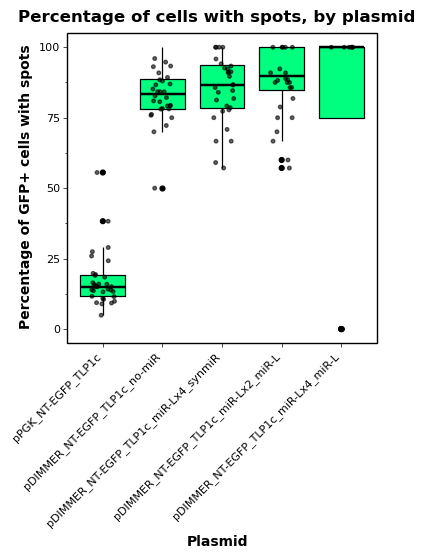

/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_jitter : Removed 6 rows containing missing values.


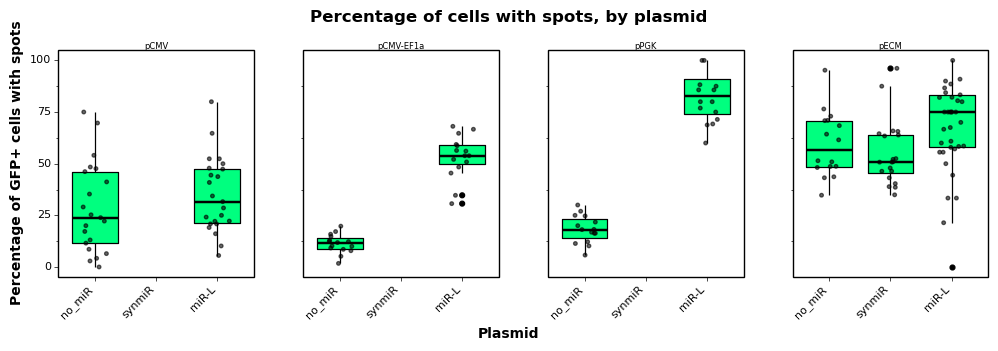

In [61]:
# Plot the results of the calculations above:

my_spots = spot_summary[(spot_summary['tx_status_taz'] == "Y") & 
(spot_summary['experiment'].isin(aug_experiments)) &
(spot_summary['plasmid'] != 'none')]


# Create a plot for experiments from August
exp1_boxplot = (
    p9.ggplot(my_spots, 
              p9.aes(x = 'plasmid', 
                     y = 'pc_rois_with_spots')) +
    p9.geom_boxplot(outlier_shape = None, 
                    color = "black", fill = "springgreen") +  # Box plot without outliers to avoid overlap with scatter points
    p9.geom_jitter(width = 0.2, size = 1, color = "black", alpha = 0.6) +  # Scatter plot with jitter for visibility
    p9.labs(title = "Percentage of cells with spots, by plasmid",
            x = "Plasmid", 
            y = "Percentage of GFP+ cells with spots") + 
    p9.scale_y_continuous(limits=(0, 100)) + 
    #p9.facet_grid('promoter ~ ') +
    p9.theme_bw() +  # Apply theme
    p9.theme(figure_size = (4, 4),
             subplots_adjust = {'wspace': 0.25},  # Adjust space between plots
             aspect_ratio = 1,
             panel_grid = p9.element_blank(), 
             panel_border = p9.element_rect(color='black', linewidth=1), 
             axis_ticks = p9.element_line(color='black', linewidth=0.5), 
             plot_title = p9.element_text(size=12, color='black', face='bold'),
             axis_text_x = p9.element_text(size=8, color='black', angle = 45, hjust = 1), 
             axis_text_y = p9.element_text(size=8, color='black'), 
             axis_title = p9.element_text(size=10, color='black', face='bold'), 
             legend_text = p9.element_text(size=8, color='black'), 
             legend_title = p9.element_text(size=10, color='black', face='bold'),
             legend_position = 'none',
             strip_background = p9.element_blank(), 
             strip_text = p9.element_text(size=6, color='black'))
)

# Create a plot for experiments switching promoters

my_spots = spot_summary[(spot_summary['tx_status_taz'] == "Y") & 
(spot_summary['experiment'].isin(oct_experiments)) &
(spot_summary['plasmid'] != 'none')]

exp2_boxplot = (
    p9.ggplot(my_spots, 
              p9.aes(x = 'miRNA', 
                     y = 'pc_rois_with_spots')) +
    p9.geom_boxplot(outlier_shape = None, 
                    color = "black", fill = "springgreen") +  # Box plot without outliers to avoid overlap with scatter points
    p9.geom_jitter(width = 0.2, size = 1, color = "black", alpha = 0.6) +  # Scatter plot with jitter for visibility
    p9.labs(title = "Percentage of cells with spots, by plasmid",
            x = "Plasmid", 
            y = "Percentage of GFP+ cells with spots") + 
    p9.scale_y_continuous(limits=(0, 100)) + 
    p9.facet_grid(' ~ promoter') +
    p9.theme_bw() +  # Apply theme
    p9.theme(figure_size = (12, 6),
             subplots_adjust = {'wspace': 0.25},  # Adjust space between plots
             aspect_ratio = 1,
             panel_grid = p9.element_blank(), 
             panel_border = p9.element_rect(color='black', linewidth=1), 
             axis_ticks = p9.element_line(color='black', linewidth=0.5), 
             plot_title = p9.element_text(size=12, color='black', face='bold'),
             axis_text_x = p9.element_text(size=8, color='black', angle = 45, hjust = 1), 
             axis_text_y = p9.element_text(size=8, color='black'), 
             axis_title = p9.element_text(size=10, color='black', face='bold'), 
             legend_text = p9.element_text(size=8, color='black'), 
             legend_title = p9.element_text(size=10, color='black', face='bold'),
             legend_position = 'none',
             strip_background = p9.element_blank(), 
             strip_text = p9.element_text(size=6, color='black'))
)

# Display the plot
print(exp1_boxplot)
print(exp2_boxplot)

In [69]:
# Save the plot to disk as a PDF file
plot_dir = os.path.join(repo_directory, "plots")
os.makedirs(plot_dir, exist_ok = True)
plot1_filename = 'pc_with_spots_Aug.pdf'  # Replace with your desired file name
plot2_filename = 'pc_with_spots_promoters.pdf' # Replace with your desired file name
exp1_boxplot.save(f"{plot_dir}/{plot1_filename}", format = 'pdf', dpi = 300) 
exp2_boxplot.save(f"{plot_dir}/{plot2_filename}", format = 'pdf', dpi = 300) 

/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 4 x 4 in image.
/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: /Users/nestor/Documents/NYU-ISG/python_image-analysis/plots/pc_with_spots_Aug.pdf
/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_jitter : Removed 14 rows containing missing values.
/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 12 x 6 in image.
/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: /Users/nestor/Documents/NYU-ISG/python_image-analysis/plots/pc_with_spots_promoters.pdf
/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_jitter : Removed 6 rows containing missing 